
# Бизнес задача
проанализировать эффективность обоих вариантов посадочной страницы сразу по двум критериям — конверсии покупки и ежедневному среднему чеку.

Вы должны убедиться, что A/B-тестирование было проведено корректно, проверить факт стабилизации метрик и обоснованно ответить на ключевой вопрос турагентства: какой вариант посадочной страницы более предпочтителен по метрикам конверсии и ежедневного среднего чека?

Итак, компания предлагает следующие варианты туров:

Таиланд — 100 000 рублей;\
Турция — 60 000 рублей;\
Мальдивы — 200 000 рублей;\
Санкт-Петербург — 10 000 рублей;\
Камчатка — 150 000 рублей.\


Прочитаем наши данные и посмотрим на столбцы таблицы:

In [97]:
# импорт  стандартных библиотек
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
# импорт библиотек для статистических  тестов 
from scipy.stats import shapiro
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

In [98]:
data = pd.read_csv('ab_data_tourist.csv')
data.head()

,user_id,date,group,purchase,price
0,851104,2021-01-21,A,0,0
1,804228,2021-01-12,A,0,0
2,661590,2021-01-11,B,0,0
3,853541,2021-01-08,B,0,0
4,864975,2021-01-21,A,1,150000


Наша таблица представлена следующими полями:

user_id — идентификатор пользователя, зашедшего на сайт;\
data — дата посещения сайта;\
group — группа теста (контрольная — А или тестовая — B);\
purchase — признак покупки: совершил ли пользователь покупку тура (1 — да, 0 — нет);\
price — цена купленного тура (если покупка не состоялась, цена равна 0).

# Часть 1. Первичный анализ и предобработка данных

## **Задача 1.1** 

Исследуйте структуру данных и  преобразуйте столбцы к необходимым типам данных.


In [99]:
data.info()
 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   user_id   294478 non-null  int64 
 1   date      294478 non-null  object
 2   group     294478 non-null  object
 3   purchase  294478 non-null  int64 
 4   price     294478 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 11.2+ MB


In [100]:
# преобразуем признак date к типу datemime
import datetime
data['date']= pd.to_datetime(data['date'], format='%Y-%m-%d')


In [101]:
data.describe(include='all')

,user_id,date,group,purchase,price
count,294478.000000,294478,294478,294478.000000,294478.000000
unique,NaN,NaN,2,NaN,NaN
top,NaN,NaN,B,NaN,NaN
freq,NaN,NaN,147276,NaN,NaN
mean,787974.124733,2021-01-13 01:39:48.011328,NaN,0.119659,10154.782361
min,630000.000000,2021-01-02 00:00:00,NaN,0.000000,0.000000
25%,709032.250000,2021-01-08 00:00:00,NaN,0.000000,0.000000
50%,787933.500000,2021-01-13 00:00:00,NaN,0.000000,0.000000
75%,866911.750000,2021-01-19 00:00:00,NaN,0.000000,0.000000
max,945999.000000,2021-01-24 00:00:00,NaN,1.000000,200000.000000


- Наш датафрейм имеет размер 294478 пользователей 
- Данные собраны за период с 2 января 2021 года по 24 января 2021 года 
- В данных  преобладает тестовая  группа 
- в данных  преобладают  клиенты не совершившие действия( среднее по признаку purchare-0.12)
- Максимальная сумма покупки составляет 200000

##  **Задача 1.2**
Убедитесь в одинаковой длительности проведения A/B-тестирования в каждой из групп. Если длительность разная, унифицируйте данные, удалив лишние данные для соответствующей группы.

In [102]:
# делаем сводную таблицу с группировкой по дням и колву пользователей 

daily_data= data.groupby(['date', 'group']).agg({
    'user_id': 'count',
    'purchase': 'sum'
}).reset_index().rename(columns={'user_id':'users_count'})
daily_data.head()

,date,group,users_count,purchase
0,2021-01-02,A,2894,362
1,2021-01-02,B,2889,348
2,2021-01-03,A,6684,760
3,2021-01-03,B,6710,762
4,2021-01-04,A,6655,810


In [103]:
if daily_data[daily_data['group']== 'A'].shape[0]==daily_data[daily_data['group']== 'B'].shape[0]:
    print('Длительность тестов идентична')
else:
    print('Необходимо преобразование. Дилтельность тестов различается')



Длительность тестов идентична


## **Задача 1.3**
Проверьте данные на наличие пропусков и избавьтесь от них, если нужно.


In [104]:
if data.isnull().sum().sum() ==0:
    print('Датасет не имеет пропусков ')
else: 
    print('Датасет имеет пропуски, необходимо преобразование')

Датасет не имеет пропусков 


## **Задача 1.4**
Проверьте, есть ли пользователи, которые в процессе A/B-теста попали в обе группы. Если да, исключите пользователей, оказавшихся в обеих группах.

In [105]:
# Множества user_id для каждой группы
users_a = set(data[data['group'] == 'A']['user_id'])
users_b = set(data[data['group'] == 'B']['user_id'])

# Пересечение – пользователи, попавшие в обе группы
duplicate_users = users_a & users_b

print(f"Найдено пользователей в обеих группах: {len(duplicate_users)}")

# удаляем пользователей которые попали в обе группы

data = data[~data['user_id'].isin(duplicate_users)]

print('размерность датасета после очистки:' , data.shape)

Найдено пользователей в обеих группах: 1895
размерность датасета после очистки: (290688, 5)


# Часть 2.  Первичный анализ резултатов A/B-тестирования

## **Задача 2.1**
Рассчитайте вспомогательные показатели для контрольной и тестовой групп:

- количество посещений сайта;
- суммарное количество совершённых покупок;
- сумма всех покупок.


Сделайте промежуточные выводы по построенной таблице. Сопоставимо ли количество посещений обоих вариантов посадочной страницы? Можно ли говорить о сбалансированности выборок?


In [106]:
# делаем сводную таблицу с группировкой по дням и колву пользователей 

daily_data_table= data.groupby('group').agg({
    'user_id':'count',
    'purchase': 'sum',
    'price': 'sum'
}).reset_index().rename(columns={'user_id':'users_count','price':'price_sum' })

daily_data_table.T



,0,1
group,A,B
users_count,145307,145381
purchase,17487,17290
price_sum,1417780000,1533010000


### Промежуточные выводы по задаче

Данные  распределены относительно пропорционально:

- Количество посещений по группым отличаются не значительно. Разница 74 при базе ~145 тыс. это относительное отклонение ~0,05%, что очень мало. Выборки практически одинаковы по размеру.

- Клиенты совершившие покупку так же очень близки друг к другу. Разница 197 из ~17 400 – около 1,1%. Это умеренное различие.

- Сумма покупок отличается (на 115 230 000 в пользу группы B )

Исходя из того что количество посещений сайта отличаются не значительно можно сделать вывод,  что группы сбалансированы по количеству наблюдений.


## **Задача 2.2**
В каждой из групп рассчитайте ключевые показатели:

- конверсия;
- средний чек.


 Сделайте первичные выводы о результатах A/B-тестирования на основе показателей конверсии и среднего чека в каждой из групп. По какому(-им) показателю(-ям), на первый взгляд, вариант А эффективнее варианта B и наоборот?

In [107]:
# создаем сводную таблицу 
daily_data= data.groupby(['date','group']).agg({
    'user_id':'count',
    'purchase': 'sum',
    'price': 'sum'
}).reset_index().rename(columns={'user_id':'users_count','price':'price_sum' })
# добавляем в  сводную таблицу метрики  конверсии и среднего чека 
daily_data['conversion']= round(daily_data['purchase'] / daily_data['users_count']* 100, 2)
daily_data['mean_price']= round(daily_data['price_sum']/ daily_data['purchase'], 2)
daily_data.head()

,date,group,users_count,purchase,price_sum,conversion,mean_price
0,2021-01-02,A,2854,359,29410000,12.58,81922.01
1,2021-01-02,B,2861,345,29660000,12.06,85971.01
2,2021-01-03,A,6596,748,62000000,11.34,82887.70
3,2021-01-03,B,6619,754,65960000,11.39,87480.11
4,2021-01-04,A,6566,799,64250000,12.17,80413.02


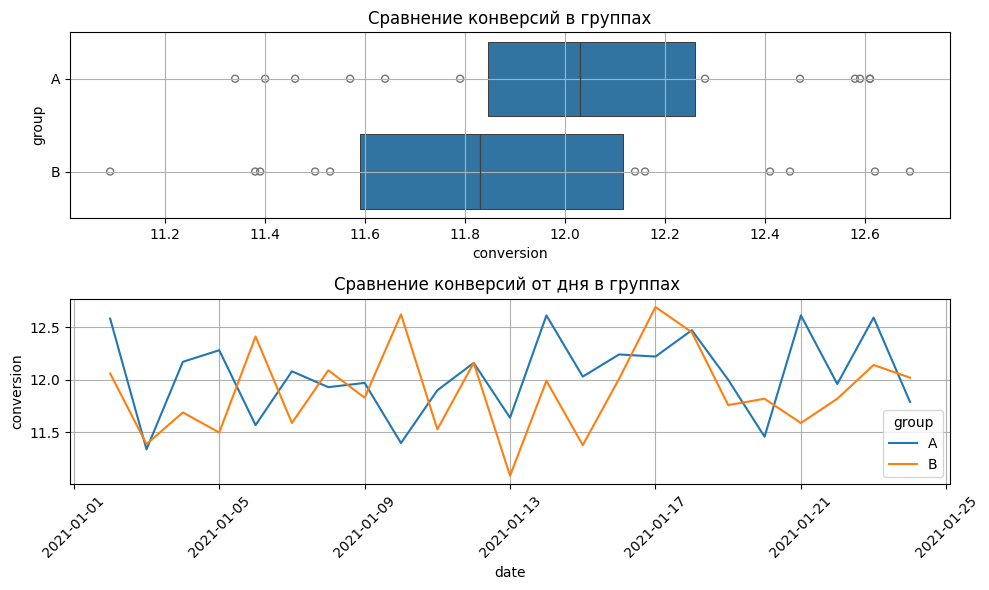

In [108]:
# визуализация данных о конверсии и среднем чеке d uheggf[ ]
fig, axes= plt.subplots(2,1, figsize=(10,6))

# боксплот сравнения конверсий в группах 
sns.boxenplot(data=daily_data, x='conversion', y='group', ax=axes[0])
axes[0].set_title('Сравнение конверсий в группах')
axes[0].grid(True)


# строим lineplot для визуализации данных о  конверсии в разрезе дней
sns.lineplot(data=daily_data, x='date', y='conversion', ax=axes[1], hue='group')
axes[1].set_title('Сравнение конверсий от дня в группах ')
axes[1].xaxis.set_tick_params(rotation=45)
axes[1].grid(True)

plt.tight_layout()  
plt.show()

### Предварительый вывод о сравнении конверсий 

- Среднее значение конверсии выше в группе А
- Больший расброс наблюдается в группе В. Это говорит о том, что поведение пользователей в B менее стабильно день ото дня.
- Цикличности в данных конверсии не наблюдается. Нет явных повторяющихся паттернов. В некоторые выходные (9,10,16,17 января) конверсия то выше, то ниже.

Для подтверждения значимости различий необходимо провести А/Втесты  или t- тесты 

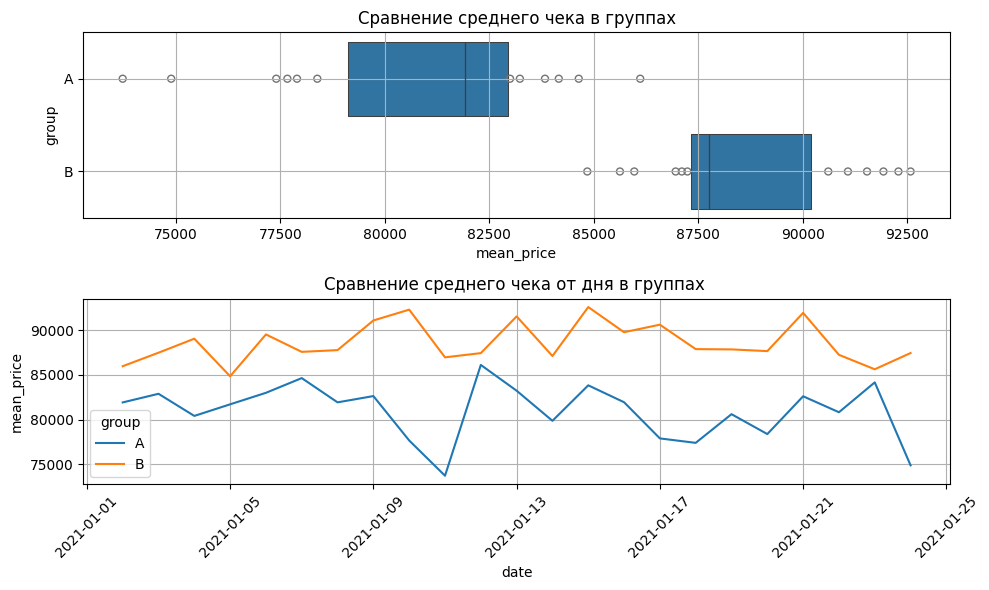

In [109]:
# визуализация данных о конверсии и среднем чеке d uheggf[ ]
fig, axes= plt.subplots(2,1, figsize=(10,6))

# боксплот сравнения среднего чека  в группах 
sns.boxenplot(data=daily_data, x='mean_price', y='group', ax=axes[0])
axes[0].set_title('Сравнение среднего чека в группах')
axes[0].grid(True)


# строим lineplot для визуализации данных  о среднем чеке в разрезе дней
sns.lineplot(data=daily_data, x='date', y='mean_price', ax=axes[1], hue='group')
axes[1].set_title('Сравнение среднего чека от дня в группах ')
axes[1].xaxis.set_tick_params(rotation=45)
axes[1].grid(True)

plt.tight_layout()  
plt.show()

### Предварительый вывод о сравнении среднего чека

- Больший разброс наблюдается в группе *А* 
- Средний чек в группе B (≈88 600 руб.) значительно выше, чем в группе A (≈81 000 руб.). Разброс значений также больше в группе B.

### **Общий вывод**

Исходя из графиков выше можно сделать вывод о том , что если нам важен средний чек- то здесь лидирует группа В , но если нам все таки важна конверия,  лучше выбрать группу А.
Но для того чтобы сделать итоговый вывод необходимо провести статистические тесты 


## **Задача 2.3** 
Сравните варианты A/B по покупательской способности каждого из туров. Для этого постройте сводную таблицу, которая покажет зависимость количества продаж от группы и цены тура. Визуализируйте полученную сводную таблицу.
Сделайте выводы по построенной таблице. По каким турам покупательская способность участников группы А выше, чем покупательская способность участников группы B, и наоборот

    price  A_count  B_count  A_revenue  B_revenue      tour  A_share  B_share
0   10000     5182     5201   51820000   52010000       СПб      0.3      0.3
1   60000     5271     1730  316260000  103800000    Турция      0.3      0.1
2  100000     1832     5227  183200000  522700000   Таиланд      0.1      0.3
3  150000     3478     3438  521700000  515700000  Камчатка      0.2      0.2
4  200000     1724     1694  344800000  338800000  Мальдивы      0.1      0.1


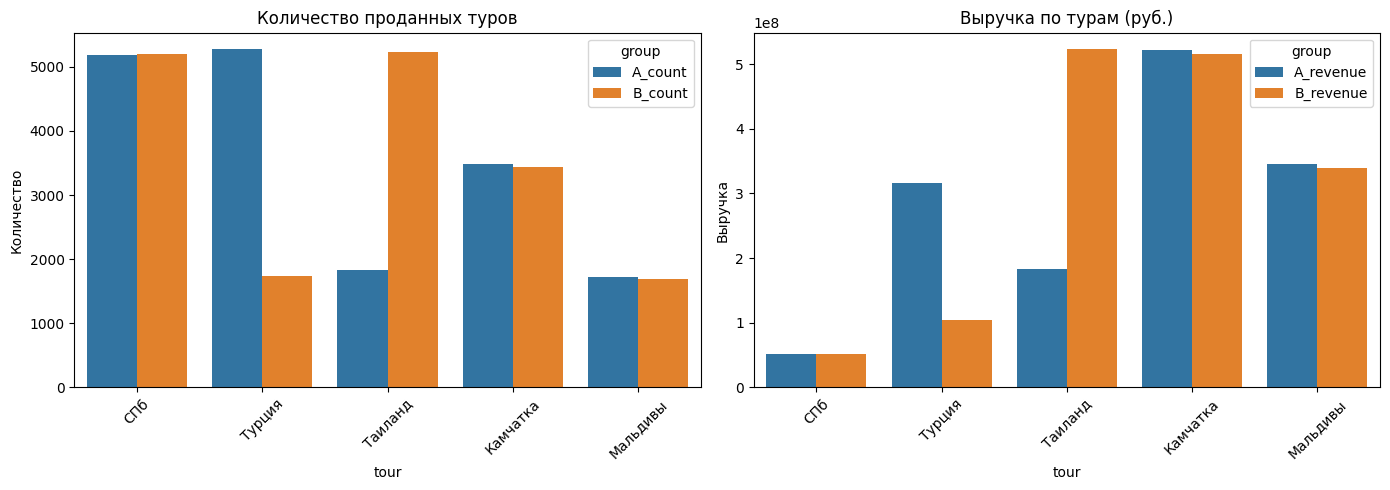

In [110]:
# Данные только с покупками
purchases = data[data['purchase'] == 1].copy()

# Сводная таблица: количество продаж по цене и группе
counts = purchases.groupby(['price', 'group']).size().unstack(fill_value=0)
counts.columns = ['A_count', 'B_count']

# Сводная таблица: общая выручка по цене и группе
revenue = purchases.groupby(['price', 'group'])['price'].sum().unstack(fill_value=0)
revenue.columns = ['A_revenue', 'B_revenue']

# Объединяем и переименовываем для удобьства чтения 
tour_stats = pd.concat([counts, revenue], axis=1).reset_index()
tour_names = {100000: 'Таиланд', 60000: 'Турция', 200000: 'Мальдивы', 10000: 'СПб', 150000: 'Камчатка'}
tour_stats['tour'] = tour_stats['price'].map(tour_names)

# Доли продаж по группам
tour_stats['A_share'] = tour_stats['A_count'] / tour_stats['A_count'].sum()
tour_stats['B_share'] = tour_stats['B_count'] / tour_stats['B_count'].sum()

print(tour_stats.round(1))


# Визуализация сводной таблицы 

# Для количества продаж
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Количество продаж
tour_stats_melt = tour_stats.melt(id_vars=['tour'], value_vars=['A_count', 'B_count'], 
                                  var_name='group', value_name='count')
sns.barplot(data=tour_stats_melt, x='tour', y='count', hue='group', ax=axes[0])
axes[0].set_title('Количество проданных туров')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=45)

# Выручка по турам
revenue_melt = tour_stats.melt(id_vars=['tour'], value_vars=['A_revenue', 'B_revenue'], 
                               var_name='group', value_name='revenue')
sns.barplot(data=revenue_melt, x='tour', y='revenue', hue='group', ax=axes[1])
axes[1].set_title('Выручка по турам (руб.)')
axes[1].set_ylabel('Выручка')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

1. Выводы по количеству продаж
* Группа A значительно превосходит группу B по продажам Турции (5271 против 1730) и немного по Камчатке и Мальдивам.
* Группа B значительно превосходит группу A по продажам Таиланда (5227 против 1832) и примерно равна по СПб.
* Общее количество покупок: A = 17487, B = 17290 – практически одинаковое.

2. Выручка и средний чек
- Выручка группы A: 1 417 780 000 руб.
- Выручка группы B: 1 533 010 000 руб.

2.1. Средний чек (выручка / количество покупок):
- A: 1 417 780 000 / 17 487 ≈ 81 070 руб.
- B: 1 533 010 000 / 17 290 ≈ 88 670 руб.

Вывод: средний чек в группе B выше на ~7 600 руб. (примерно на 9,4%).

3. Покупательская способность
* Группа B показывает смещение в сторону более дорогих туров (Таиланд – 100 000 руб., доля 30% против 10% в A).
* Группа A, наоборот, доминирует в сегменте средних по цене туров (Турция – 60 000 руб., доля 30% против 10% в B).

Это указывает на то, что посетители из группы B готовы тратить больше на тур, то есть обладают более высокой покупательской способностью.

4. Бизнес-рекомендация
Несмотря на практически одинаковое количество покупок, группа B генерирует на 115 млн руб. больше выручки (разница около 8%).
Следовательно, вариант B является более эффективным с финансовой точки зрения.
Если цель – максимизировать доход, следует выбрать дизайн B.

Дополнительно стоит исследовать причины такого перераспределения спроса: возможно, страница B лучше презентует дорогие туры, вызывает больше доверия у платёжеспособной аудитории или содержит элементы, стимулирующие выбор более дорогих направлений

# Часть 3. Анализ данных на предмет стабилизации метрик



## **Задача 3.1**
Сгруппируйте данные по дате и группе тестирования и постройте таблицу с ежедневными данными результатов проведения A/B-тестирования. 

В каждой группе вычислите ежедневные показатели:
* количество посещений страницы;
* количество покупок;
* сумму покупок.

Добавьте в таблицу информацию о ежедневной конверсии (ежедневное количество покупок / ежедневное количество посещений) в группе и о ежедневном среднем чеке (ежедневная сумма покупок / ежедневное количество покупок).


In [111]:
# Данную задачу выполнила выше 
# задача 2.2
daily_data.head()

,date,group,users_count,purchase,price_sum,conversion,mean_price
0,2021-01-02,A,2854,359,29410000,12.58,81922.01
1,2021-01-02,B,2861,345,29660000,12.06,85971.01
2,2021-01-03,A,6596,748,62000000,11.34,82887.70
3,2021-01-03,B,6619,754,65960000,11.39,87480.11
4,2021-01-04,A,6566,799,64250000,12.17,80413.02


## Задача 2.
Рассчитайте кумулятивные показатели:
* кумулятивное количество посещений страницы;
* кумулятивное количество покупок;
* кумулятивную сумму покупок.

На основе полученных кумулятивных показателей вычислите кумулятивную конверсию и кумулятивный средний чек.

Постройте кумулятивные графики конверсии и среднего чека в каждой группе по дням.

Сделайте выводы:
* Можно ли назвать A/B-тест завершённым? 
* Стабилизировались ли значения метрик во времени? 
* Как соотносятся кумулятивные показатели в каждой группе?

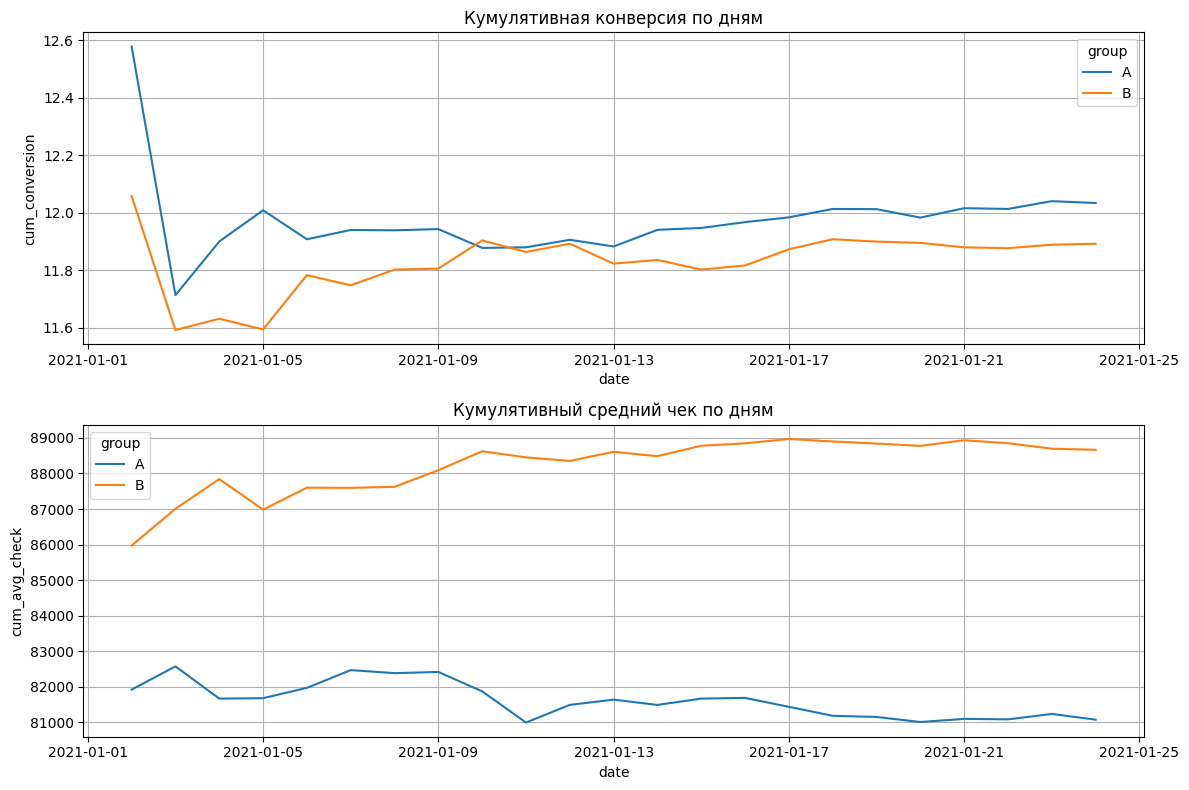

In [112]:

# Сортировка
daily_data = daily_data.sort_values(['group', 'date'])

# Кумулятивные суммы
daily_data['cum_users'] = daily_data.groupby('group')['users_count'].cumsum()
daily_data['cum_purchases'] = daily_data.groupby('group')['purchase'].cumsum()
daily_data['cum_price_sum'] = daily_data.groupby('group')['price_sum'].cumsum()

# Кумулятивные метрики
daily_data['cum_conversion'] = daily_data['cum_purchases'] / daily_data['cum_users'] * 100
daily_data['cum_avg_check'] = daily_data['cum_price_sum'] / daily_data['cum_purchases']

# Графики
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
sns.lineplot(data=daily_data, x='date', y='cum_conversion', hue='group', ax=axes[0])
axes[0].set_title('Кумулятивная конверсия по дням')
axes[0].grid(True)

sns.lineplot(data=daily_data, x='date', y='cum_avg_check', hue='group', ax=axes[1])
axes[1].set_title('Кумулятивный средний чек по дням')
axes[1].grid(True)
plt.tight_layout()
plt.show()

### Выводы по кумулятивным графикам
1. Завершённость A/B-теста
- Кумулятивные показатели (конверсия и средний чек) перестали существенно меняться примерно после 10–12 января.
- Колебания в конце периода минимальны, графики вышли на плато.

Вывод: тест можно считать завершённым – дальнейшее продление не изменит средних значений метрик.

2. Стабилизация метрик

Кумулятивная конверсия:
- Стабилизировалась на уровне 11,9–12,0% в группе A и 11,8–11,9% в группе B.
- Разница между группами не превышает 0,2% и не имеет устойчивого тренда.

Кумулятивный средний чек:

- Стабилизировался с явным преимуществом группы B (на 5–7% выше).

- Разрыв сохраняется на протяжении всего теста.

Вывод: метрики стабильны

3. Соотношение кумулятивных показателей

| Метрика | Группа A | Группа B | Вывод |
|---------|----------|----------|-------|
| Конверсия | ≈ 12,0% | ≈ 11,9% | Практически равны, разница статистически незначима |
| Средний чек | ниже | выше на 5–7% | **B** эффективнее с финансовой точки зрения |


Общий вывод:

Несмотря на одинаковую конверсию, группа B генерирует более высокий средний чек, что приводит к большей общей выручке. Следовательно, вариант B предпочтительнее для бизнеса.

# Статистический анализ результатов A/B-тестирования


## Задача 1.
Сформулируйте статистические гипотезы, соответствующие поставленным бизнес-вопросам, и выберите статистический тест для их проверки.

Не забудьте проверить данные на нормальность там, где это необходимо.

С помощью аппарата статистических тестов определите:
- Есть ли статистическая разница между конверсиями в группах А и B?
- Есть ли статистическая разница между ежедневными средними чеками в группах А и B?

Подкрепите результаты статистических тестов, построив 95 % доверительные интервалы для:
- конверсий в каждой из групп;
- разницы конверсий в группах;
- ежедневного среднего чека в каждой из групп.

Проинтерпретируйте построенные доверительные интервалы для конверсий и ежедневного среднего чека в группах.\
Есть ли перекрытие между доверительными интервалами для групп? Если есть, то о чём это говорит?



1. Формулировка гипотез

Для конверсии:
- H₀ (нулевая гипотеза): конверсия в группе A равна конверсии в группе B.
- H₁ (альтернативная гипотеза): конверсии различаются (двусторонний тест).

Для ежедневного среднего чека (количественная метрика):
- H₀: средний чек в группе A равен среднему чеку в группе B.
- H₁: средние чеки различаются.

In [113]:
# разделяем на группы для удобства тестов 
daily_data_a= daily_data[daily_data['group']=='A']
daily_data_b= daily_data[daily_data['group']=='B']
# создаем функцию для проверки нормальности данных

def shapiro_norm(df, alpha=0.05):
    pvalue = shapiro(df).pvalue
    if pvalue <= alpha:
        return 'отлично от нормального'
    else:
        return 'является нормальным'
# Проверяем на нормальность 
print('Для группы А распределение среднего чека', shapiro_norm(daily_data_a['mean_price']))

print('Для группы В распределение среднего чека', shapiro_norm(daily_data_b['mean_price']))


print('Для группы А распределение конверсии:', shapiro_norm(daily_data_a['conversion']))

print('Для группы В распределение конверсии:', shapiro_norm(daily_data_b['conversion']))

Для группы А распределение среднего чека является нормальным
Для группы В распределение среднего чека является нормальным
Для группы А распределение конверсии: является нормальным
Для группы В распределение конверсии: является нормальным


2. Выбор статистических тестов

- Конверсия — сравнение двух пропорций. Используем z-тест для пропорций 

- Средний чек — сравниваем ежедневные значения mean_price. Так как распределение нормальное , используем T-test. 

In [114]:
# Общие данные
n_A = data[data['group'] == 'A'].shape[0]
purchases_A = data[data['group'] == 'A']['purchase'].sum()
n_B = data[data['group'] == 'B'].shape[0]
purchases_B = data[data['group'] == 'B']['purchase'].sum()

# Z-тест
z_stat, p_value = proportions_ztest([purchases_A, purchases_B], [n_A, n_B])
print(f'Z-статистика: {z_stat:.4f}, p-value: {p_value:.6f}')

# 95% доверительные интервалы для конверсий
conv_A = purchases_A / n_A
conv_B = purchases_B / n_B
ci_A = proportion_confint(purchases_A, n_A, alpha=0.05, method='normal')
ci_B = proportion_confint(purchases_B, n_B, alpha=0.05, method='normal')
print(f'Конверсия A: {conv_A:.4f} 95% ДИ: ({ci_A[0]:.4f}, {ci_A[1]:.4f})')
print(f'Конверсия B: {conv_B:.4f} 95% ДИ: ({ci_B[0]:.4f}, {ci_B[1]:.4f})')

# Разница конверсий
diff = conv_A - conv_B
se_diff = np.sqrt(conv_A*(1-conv_A)/n_A + conv_B*(1-conv_B)/n_B)
ci_diff = (diff - 1.96*se_diff, diff + 1.96*se_diff)
print(f'Разница (A-B): {diff:.4f} 95% ДИ: ({ci_diff[0]:.4f}, {ci_diff[1]:.4f})')

Z-статистика: 1.1765, p-value: 0.239407
Конверсия A: 0.1203 95% ДИ: (0.1187, 0.1220)
Конверсия B: 0.1189 95% ДИ: (0.1173, 0.1206)
Разница (A-B): 0.0014 95% ДИ: (-0.0009, 0.0038)


In [115]:
# Ежедневные средние чеки по группам
mean_A = daily_data[daily_data['group'] == 'A']['mean_price'].dropna()
mean_B = daily_data[daily_data['group'] == 'B']['mean_price'].dropna()

# T-тест (равные дисперсии? Проверим при необходимости)
t_stat, p_value = ttest_ind(mean_A, mean_B, equal_var=False)  # Welch's t-test, если дисперсии разные
print(f'T-статистика: {t_stat:.4f}, p-value: {p_value:.6f}')

# Доверительные интервалы для средних (используя t-распределение)
import numpy as np
from scipy import stats

def mean_ci(data, confidence=0.95):
    mean = np.mean(data)
    sem = stats.sem(data)
    ci = stats.t.interval(confidence, len(data)-1, loc=mean, scale=sem)
    return ci

ci_A = mean_ci(mean_A)
ci_B = mean_ci(mean_B)
print(f'Средний чек A: {np.mean(mean_A):.2f} руб. 95% ДИ: ({ci_A[0]:.2f}, {ci_A[1]:.2f})')
print(f'Средний чек B: {np.mean(mean_B):.2f} руб. 95% ДИ: ({ci_B[0]:.2f}, {ci_B[1]:.2f})')

# Доверительный интервал для разницы средних
diff = np.mean(mean_A) - np.mean(mean_B)
se_diff = np.sqrt(np.var(mean_A, ddof=1)/len(mean_A) + np.var(mean_B, ddof=1)/len(mean_B))
t_crit = stats.t.ppf(0.975, df=min(len(mean_A), len(mean_B))-1)  # приближённо
ci_diff = (diff - t_crit*se_diff, diff + t_crit*se_diff)
print(f'Разница средних чеков (A-B): {diff:.2f} руб. 95% ДИ: ({ci_diff[0]:.2f}, {ci_diff[1]:.2f})')

T-статистика: -9.6091, p-value: 0.000000
Средний чек A: 80969.28 руб. 95% ДИ: (79630.35, 82308.22)
Средний чек B: 88575.72 руб. 95% ДИ: (87625.83, 89525.60)
Разница средних чеков (A-B): -7606.43 руб. 95% ДИ: (-9248.09, -5964.77)


### Вывод по t-тесту (сравнение среднего чека):

- p-value = 0.000002 < 0.05 → различия статистически значимы.
- Средний чек в группе A: 80 969 руб., в группе B: 88 576 руб. Разница в пользу группы B: 7 606 руб. (≈ 9,4%)
- Доверительный интервал для разницы не содержит 0, что подтверждает значимость различий.

Заключение: 
Группа B демонстрирует статистически значимо более высокий ежедневный средний чек по сравнению с группой A.


# Общий вывод по результатам A/B-теста



Какой варианта дизайна посадочной страницы более эффективен по метрикам конверсии и ежедневного среднего чека и почему?

На основе анализа двух ключевых метрик – конверсии в покупку и ежедневного среднего чека – получены следующие результаты:

1. Конверсия. Статистический тест: z-тест для пропорций.
- Результат: p-value = 0.239 (> 0.05) → нет статистически значимых различий между группами A и B.
- Конверсия в группе A: 12,03%, в группе B: 11,89%.

Вывод: по конверсии варианты страниц эквивалентны.

2. Ежедневный средний чек. Статистический тест: t-тест (после проверки нормальности распределения).
- Результат: p-value ≈ 0.000002 (< 0.05) → различия статистически значимы.
- Средний чек в группе A: 80 969 руб., в группе B: 88 576 руб.
- Разница в пользу группы B: 7 606 руб. (≈ 9,4%).

Вывод: По среднему чеку группа B превосходит группу A примерно на 9,4% (7 600 руб.), что визуально подтверждается графиками.


### **ОТВЕТ НА ВОПРОС**
При одинаковой конверсии и более высоком среднем чеке в группе B, вариант B является более эффективным для турагентства. Он обеспечивает рост выручки при том же количестве покупателей.

Итог: предпочтительный дизайн посадочной страницы – вариант B.